<a href="https://colab.research.google.com/github/zelaneroz/sc4000_chatbot_area/blob/main/ChatBotArena_SC4000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LMSYS - Chatbot Arena Human Preference Predictions
[Kaggle Link](https://www.kaggle.com/competitions/lmsys-chatbot-arena/)

Nanyang Technological University
SC4000: Machine Learning
Course Project

**Members**:
* Albinowski, Wiktor Marcin (N2500433A)
* Chelashaw, Joshua Ruigu  (N2500531J)
* Espanto, Zelan Eroz (N2500107L)
* Skendri, Noussayba (N2500525K)
* Umeh, Sophia Chiarapunam (N2503901B)


**Challenge Description**
* Ensuring LLMS' responses resonate with users is critical for successful interaction.
* Predict which response a user will prefer in these head-to-head battles.

This challenge aligns with the concept of "reward models" or "preference models" in reinforcement learning from human feedback (RLHF). Previous research has identified limitations in directly prompting an existing LLM for preference predictions. These limitations often stem from biases such as favoring responses presented first (position bias), being overly verbose (verbosity bias), or exhibiting self-promotion (self-enhancement bias).



**Dataset Descrption**

Dataset collected from Chatbot Arena, where users chat with two anonymous LLMs and choose the answer they prefer.

**Evaluation**
Evaluated on the log loss between the predicted probabilities and the ground truth values (with 'eps=auto').


The submission file should contain a header and have the following format:
```
 id,winner_model_a,winner_model_b,winner_tie
 136060,0.33,0,33,0.33
 211333,0.33,0,33,0.33
 1233961,0.33,0,33,0.33
 etc
```


# 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
BASE_PATH = 'MyDrive/Acads/Spring26'
df = pd.read_csv(f'/content/drive/{BASE_PATH}/train.csv')
df.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


#  I. Exploratory Data Analysis (EDA)

In [ ]:
# How many models are there and variations per model?
# How often are each model preferred?
# how many models tie? and which pairings often tie?
# how many datapoints are there?

#is there a way to differentiate the prompts? [morals, mathematics, logical, generate, etc] and is there a preference for a particular model for a particular task

Total Unique Models: 64
['gpt-4-1106-preview' 'koala-13b' 'gpt-3.5-turbo-0613' 'llama-2-13b-chat'
 'vicuna-13b' 'mixtral-8x7b-instruct-v0.1' 'gemini-pro' 'gpt-4-0314'
 'vicuna-7b' 'chatglm3-6b' 'pplx-70b-online' 'mpt-30b-chat'
 'llama2-70b-steerlm-chat' 'claude-1' 'claude-2.1' 'chatglm-6b'
 'claude-instant-1' 'dolly-v2-12b' 'claude-2.0' 'deepseek-llm-67b-chat'
 'openchat-3.5' 'starling-lm-7b-alpha' 'gpt-4-0125-preview'
 'llama-2-7b-chat' 'gpt-4-0613' 'wizardlm-70b' 'stablelm-tuned-alpha-7b'
 'vicuna-33b' 'chatglm2-6b' 'dolphin-2.2.1-mistral-7b' 'llama-2-70b-chat'
 'llama-13b' 'palm-2' 'wizardlm-13b' 'codellama-34b-instruct'
 'gemini-pro-dev-api' 'gpt-3.5-turbo-0314' 'gpt-3.5-turbo-1106'
 'yi-34b-chat' 'oasst-pythia-12b' 'qwen-14b-chat' 'alpaca-13b'
 'qwen1.5-72b-chat' 'gpt-3.5-turbo-0125' 'pplx-7b-online'
 'qwen1.5-4b-chat' 'fastchat-t5-3b' 'solar-10.7b-instruct-v1.0'
 'mistral-medium' 'nous-hermes-2-mixtral-8x7b-dpo' 'zephyr-7b-beta'
 'openhermes-2.5-mistral-7b' 'mistral-7b-instruct' 

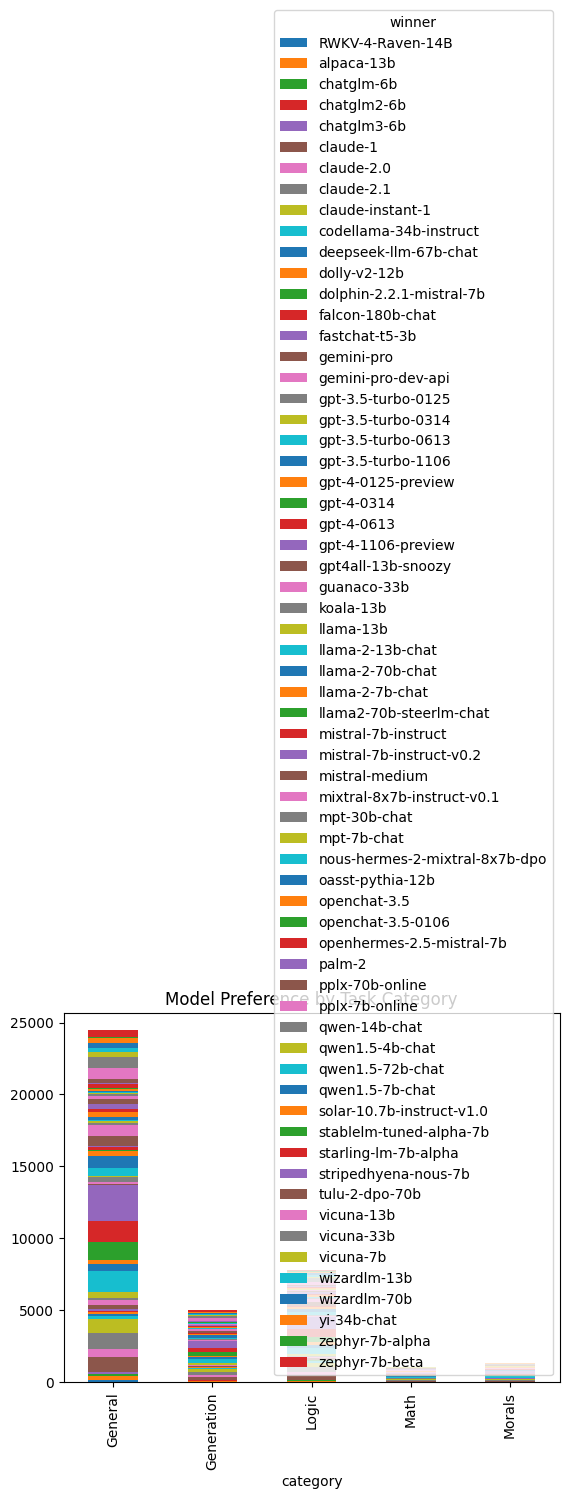

In [ ]:
# 1. Model Variations
all_models = pd.concat([df['model_a'], df['model_b']])
print(f"Total Unique Models: {all_models.nunique()}")
print(all_models.unique())

# 2. Preference Frequency
model_wins = pd.Series(dtype=int)
for idx, row in df.iterrows():
    if row['winner_model_a'] == 1:
        model_wins[row['model_a']] = model_wins.get(row['model_a'], 0) + 1
    elif row['winner_model_b'] == 1:
        model_wins[row['model_b']] = model_wins.get(row['model_b'], 0) + 1

# 3. Tie Analysis
tie_df = df[df['winner_tie'] == 1].copy()
tie_df['pair'] = tie_df.apply(lambda x: "-".join(sorted([x['model_a'], x['model_b']])), axis=1)
print(tie_df['pair'].value_counts())

# 4. Prompt Classification (Simple Keyword Approach)
def categorize(p):
    p = str(p).lower()
    if any(w in p for w in ['moral', 'ethic', 'right']): return 'Morals'
    if any(w in p for w in ['solve', 'math', 'calculate']): return 'Math'
    if any(w in p for w in ['logic', 'if', 'puzzle']): return 'Logic'
    if any(w in p for w in ['write', 'poem', 'create']): return 'Generation'
    return 'General'

df['category'] = df['prompt'].apply(categorize)

# 5. Preference per Task
df['winner'] = df.apply(lambda r: r['model_a'] if r['winner_model_a']==1 else (r['model_b'] if r['winner_model_b']==1 else 'Tie'), axis=1)
category_pref = df[df['winner'] != 'Tie'].groupby(['category', 'winner']).size().unstack(fill_value=0)

# Visualization
category_pref.plot(kind='bar', stacked=True)
plt.title('Model Preference by Task Category')
plt.show()

# II. Data Cleaning

# III. Data Modeling

# IV. Results & Predictions